In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

from integrator import Integrator
from subtractor import Subtractor
from source import Source

In [ ]:
source = Source(name='source')
source.group = "Source"
subtractor_outer = Subtractor(name='subtractor_outer')
subtractor_outer.group = "Subtractors"
subtractor_inner = Subtractor(name='subtractor_inner')
subtractor_inner.group = "Subtractors"
integrator = Integrator(name='integrator')
integrator.group = "Integrator"

components = [source, subtractor_outer, subtractor_inner, integrator]

for comp in components:
    comp.initialize(0)
    inputs = {}
    outputs = {}
    for inp, port in comp.inputs.items():
        inputs[inp] = port.value
    for outp, port in comp.outputs.items():
        outputs[outp] = port.value
    print(f"Component: {comp.name}")
    print(f"  Inputs: {inputs}")
    print(f"  Outputs: {outputs}")
    print()

Component: source
  Inputs: {}
  Outputs: {'output': 1}

Component: subtractor_outer
  Inputs: {'input1': 0.0, 'input2': 0.0}
  Outputs: {'output': 0.0}

Component: subtractor_inner
  Inputs: {'input1': 0.0, 'input2': 0.0}
  Outputs: {'output': 0.0}

Component: integrator
  Inputs: {'input': None}
  Outputs: {'output': 0.0}



In [18]:
from SysSimX.system.connection import Connection
from SysSimX.system.system import System

c1 = Connection(src_comp=source.name, src_port=source.output_specs['output'].name,
                dst_comp=subtractor_outer.name, dst_port=subtractor_outer.input_specs['input1'].name)

c2 = Connection(src_comp=subtractor_outer.name, src_port=subtractor_outer.output_specs['output'].name,
                dst_comp=subtractor_inner.name, dst_port=subtractor_inner.input_specs['input1'].name)

c3 = Connection(src_comp=subtractor_inner.name, src_port=subtractor_inner.output_specs['output'].name,
                dst_comp=integrator.name, dst_port=integrator.input_specs['input'].name)

# Algebaraic loop connection - direct feedthrough
c4 = Connection(src_comp=subtractor_inner.name, src_port=subtractor_inner.output_specs['output'].name,
                dst_comp=subtractor_inner.name, dst_port=subtractor_inner.input_specs['input2'].name)

# Feedback from integrator output to subtractor_outer
c5 = Connection(src_comp=integrator.name, src_port=integrator.output_specs['output'].name,
                dst_comp=subtractor_outer.name, dst_port=subtractor_outer.input_specs['input2'].name)

connections = [c1, c2, c3, c4, c5]

system = System(name="Algebraic Loop System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

# Adding the same connection again to test validation
system.compute_execution_order()

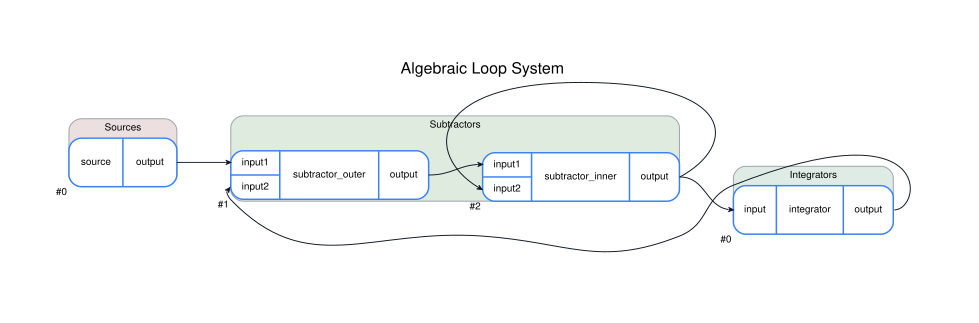

In [19]:
from SysSimX.viz.sysgraph import SystemGraphVisualizer
visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [5]:
t = 0; t_end = 10
system.initialize(t, t_end=t_end)
system.initialize(t, t_end=t_end)

In [6]:
system.run(t, t_end, dt=0.001)

In [7]:
t_vals, int_vals = zip(*integrator.outputs['output'].history)

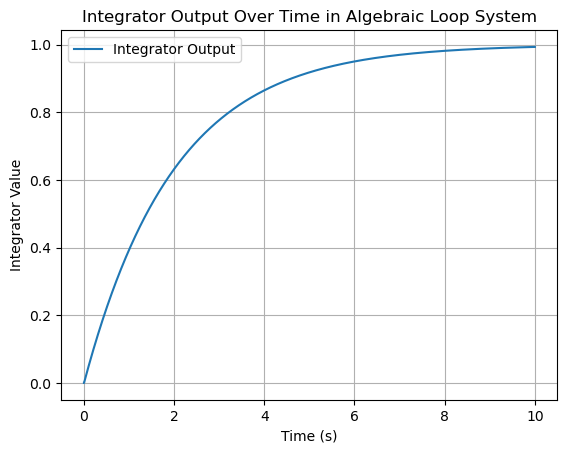

In [8]:
import matplotlib.pyplot as plt
plt.plot(t_vals, int_vals, label='Integrator Output')
plt.xlabel('Time (s)')
plt.ylabel('Integrator Value')
plt.title('Integrator Output Over Time in Algebraic Loop System')
plt.legend()
plt.grid()
plt.show()


----------------------------

In [9]:
def F(y: float) -> float:
    old_out = subtractor_inner.outputs['output'].get()
    old_in = subtractor_inner.inputs['input2'].get()
    subtractor_inner.inputs['input2'].set(y, t=0.0)
    subtractor_inner.do_step(t=0.0, dt=0.0)
    y_out = subtractor_inner.outputs['output'].get()
    # Reset to old values
    subtractor_inner.inputs['input2'].set(old_in, t=0.0)
    subtractor_inner.outputs['output'].set(old_out, t=0.0)
    return y_out

In [10]:
subtractor_inner.set_inputs({'input1': 1.0, 'input2': 0.0}, t=0.0)
subtractor_inner.do_step(t=0.0, dt=0.0)
y = subtractor_inner.get_outputs()['output']

for _ in range(10):
    Fy = F(y)
    g = y - Fy
    if abs(g) < 1e-6:
        break
    # Numerical derivative
    eps = 1e-8 * (1.0 + abs(y))
    Fp = F(y + eps)
    Fm = F(y - eps)
    dF = (Fp - Fm) / (2 * eps)
    dg = 1.0 - dF
    if abs(dg) < 1e-12:
        print("Derivative too small, stopping iteration.")
        y = Fy
    else:
        y = y - g / dg
    
    # Commit the solution to the component
    subtractor_inner.outputs['output'].set(y, t=0.0)
    subtractor_inner.inputs['input2'].set(y, t=0.0)


In [11]:
subtractor_inner.get_outputs()

{'output': 0.5000000005623004}

In [12]:
subtractor_inner.inputs

{'input1': PortState(spec=PortSpec(name='input1', type=<PortType.REAL: 'real'>, direction='in', unit=None, description=None), value=1.0, t_last=0.0, history=[(0.0, 0.0), (0.0, 0.0), (0.0, 0.0), (0, 0.0), (0.001, 1.0), (0.002, 1.0), (0.003, 1.0), (0.004, 0.9995), (0.005, 0.999), (0.006, 0.9985), (0.007, 0.99800025), (0.008, 0.99750075), (0.009000000000000001, 0.9970015), (0.010000000000000002, 0.996502499875), (0.011000000000000003, 0.9960037495), (0.012000000000000004, 0.99550524875), (0.013000000000000005, 0.9950069975000625), (0.014000000000000005, 0.9945089956253125), (0.015000000000000006, 0.9940112430009375), (0.016000000000000007, 0.9935137395021875), (0.017000000000000008, 0.9930164850043748), (0.01800000000000001, 0.9925194793828743), (0.01900000000000001, 0.9920227225131233), (0.02000000000000001, 0.991526214270621), (0.02100000000000001, 0.9910299545309296), (0.022000000000000013, 0.990533943169673), (0.023000000000000013, 0.9900381800625377), (0.024000000000000014, 0.9895426